# Load , Explore and Clean Chess_games

In [1]:
# load chess from URL
import sys
sys.path.append('../src')
from fetch_data import load_data

url = 'https://drive.google.com/file/d/1eR3NZtwIC6ECN3vhtrynqmx8okG0twA7/view?usp=sharing'
file_id = url.split('/')[5]
url = f'https://drive.google.com/uc?id={file_id}'

games_df = load_data(url, '../data/raw/chess_games.csv')

Loading from cache: ../data/raw/chess_games.csv


#### Q1: How many records are in the dataset?

In [2]:
games_df.shape

(20058, 17)

- Q1: How many records are in the dataset?
  - 20,058 rows

#### Q2: How many exact duplicate rows exist?

In [3]:
games_df.duplicated().sum()

np.int64(0)

- Q2: How many exact duplicate rows exist?
  - 0 duplicated rows

#### Q3: How many games have duplicate move sequences?

In [4]:

duplicate_games = games_df.duplicated(subset='moves').sum()
print(duplicate_games)

1138


- Q3: How many games have duplicate move sequences?
   - 1,138

#### Q4: What % of opening_response is missing?

In [5]:
games_df['opening_response'].isna().sum() / len(games_df) *100

np.float64(93.982450892412)

- Q4: What % of opening_response is missing?
   - 93.98%

#### Q5: What % of opening_variation is missing?

In [6]:
games_df['opening_variation'].isna().sum() / len(games_df) *100

np.float64(28.218167314787117)

- Q5: What % of opening_variation is missing?
   - 28.21%

#### Q6: What is the minimum number of turns in any game? Why is this suspicious?

In [7]:
games_df['turns'].min()

np.int64(1)

In [8]:
games_df.loc[games_df['turns'].idxmin()]

game_id                           1947
rated                             True
turns                                1
victory_status                  Resign
winner                           Black
time_increment                    10+0
white_id                  serik-astana
white_rating                      1464
black_id                    brorael357
black_rating                      1355
moves                               g3
opening_code                       A00
opening_moves                        1
opening_fullname     Hungarian Opening
opening_shortname    Hungarian Opening
opening_response                   NaN
opening_variation                  NaN
Name: 1946, dtype: object

- Q6: What is the minimum number of turns in any game? Why is this suspicious?
   - 1 turn ,  One move then resign/time out.

In [9]:
import sys
sys.path.append('../src')
from clean_chess import clean_chess

In [10]:
games_df = clean_chess(games_df)
print("Clean done! Shape:", games_df.shape)
print("Columns:", games_df.columns.tolist())

Clean done! Shape: (20058, 21)
Columns: ['game_id', 'rated', 'turns', 'victory_status', 'winner', 'time_increment', 'white_id', 'white_rating', 'black_id', 'black_rating', 'moves', 'opening_code', 'opening_moves', 'opening_fullname', 'opening_shortname', 'opening_variation', 'time_base', 'time_inc', 'rating_diff', 'opening_family', 'is_suspicious']


#### Q7: After adding rating_diff, what % of games did the higher-rated player win?

In [11]:
games_df['winner'].value_counts(normalize = True)

winner
White    0.498604
Black    0.454033
Draw     0.047363
Name: proportion, dtype: float64

In [12]:
non_draw = games_df[games_df['winner']!= 'Draw']
non_draw

,game_id,rated,turns,victory_status,winner,time_increment,white_id,white_rating,black_id,black_rating,...,opening_code,opening_moves,opening_fullname,opening_shortname,opening_variation,time_base,time_inc,rating_diff,opening_family,is_suspicious
0,1,False,13,Out of Time,White,15+2,bourgris,1500,a-00,1191,...,D10,5,Slav Defense: Exchange Variation,Slav Defense,Exchange Variation,15,2,309,Slav Defense,False
1,2,True,16,Resign,Black,5+10,a-00,1322,skinnerua,1261,...,B00,4,Nimzowitsch Defense: Kennedy Variation,Nimzowitsch Defense,Kennedy Variation,5,10,61,Nimzowitsch Defense,False
2,3,True,61,Mate,White,5+10,ischia,1496,a-00,1500,...,C20,3,King's Pawn Game: Leonardis Variation,King's Pawn Game,Leonardis Variation,5,10,-4,King's Pawn Game,False
3,4,True,61,Mate,White,20+0,daniamurashov,1439,adivanov2009,1454,...,D02,3,Queen's Pawn Game: Zukertort Variation,Queen's Pawn Game,Zukertort Variation,20,0,-15,Queen's Pawn Game,False
4,5,True,95,Mate,White,30+3,nik221107,1523,adivanov2009,1469,...,C41,5,Philidor Defense,Philidor Defense,NaN,30,3,54,Philidor Defense,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,20054,True,24,Resign,White,10+10,belcolt,1691,jamboger,1220,...,A80,2,Dutch Defense,Dutch Defense,NaN,10,10,471,Dutch Defense,False
20054,20055,True,82,Mate,Black,10+0,jamboger,1233,farrukhasomiddinov,1196,...,A41,2,Queen's Pawn,Queen's Pawn,NaN,10,0,37,Queen's Pawn,False
20055,20056,True,35,Mate,White,10+0,jamboger,1219,schaaksmurf3,1286,...,D00,3,Queen's Pawn Game: Mason Attack,Queen's Pawn Game,Mason Attack,10,0,-67,Queen's Pawn Game,False
20056,20057,True,109,Resign,White,10+0,marcodisogno,1360,jamboger,1227,...,B07,4,Pirc Defense,Pirc Defense,NaN,10,0,133,Pirc Defense,False


In [13]:
higher_rated_won = (
    ((non_draw['winner'] == 'White') & (non_draw['rating_diff'] > 0)) |
    ((non_draw['winner'] == 'Black') & (non_draw['rating_diff'] < 0))
)
print(f"Q7: {higher_rated_won.mean() * 100:.1f}% of non-draw games")

Q7: 64.6% of non-draw games


#### Q8: How many games are flagged as suspicious (< 5 turns)?

In [14]:
print(f"{games_df['is_suspicious'].sum()} games")

342 games


#### Q9: How many unique opening families exist?

In [15]:
games_df['opening_family'].nunique()

227

#### Q10 : Win rate for White, Black, Draw (% of total games)

In [16]:
games_df['winner'].value_counts(normalize=True).mul(100).round(2)

winner
White    49.86
Black    45.40
Draw      4.74
Name: proportion, dtype: float64

#### Q11: Most common victory_status

In [17]:
games_df['victory_status'].value_counts(normalize= True).mul(100).round(2)

victory_status
Resign         55.57
Mate           31.53
Out of Time     8.38
Draw            4.52
Name: proportion, dtype: float64

#### Q12: victory_status with highest average turns

In [18]:
games_df.groupby('victory_status')['turns'].mean().sort_values(ascending=False).round(2)

victory_status
Draw           83.78
Out of Time    72.74
Mate           65.42
Resign         53.91
Name: turns, dtype: float64

#### Q13: Most popular opening family when Black wins / White wins

In [19]:
subset = games_df[games_df['winner'] == 'White']['opening_family']
counts = subset.value_counts()
top = counts.idxmax()
count = counts.iloc[0]
print(f"White wins -> {top} ({count} games)")

White wins -> Sicilian Defense (1173 games)


In [20]:
subset = games_df[games_df['winner'] == 'Black']['opening_family']
counts = subset.value_counts()
top = counts.idxmax()
count = counts.iloc[0]
print(f"Black wins -> {top} ({count} games)")

Black wins -> Sicilian Defense (1273 games)


#### Q14 — Rated vs Unrated White win rate

In [21]:
for rated_val, label in [(True, 'Rated'), (False, 'Unrated')]:
    mask = games_df['rated'] == rated_val
    rate = (games_df[mask]['winner'] == 'White').mean() * 100
    print(f"  {label}: {rate:.2f}%")

  Rated: 49.84%
  Unrated: 49.94%


#### Q15 — Classify Short / Medium / Long using apply()

In [22]:
def classify_game(turns):
    if turns < 20:
        return 'Short'
    elif turns <= 40:
        return 'Medium'
    else:
        return 'Long'

games_df['game_length'] = games_df['turns'].apply(classify_game)
print(games_df['game_length'].value_counts(normalize = True).mul(100).round(2))

game_length
Long      70.37
Medium    21.35
Short      8.28
Name: proportion, dtype: float64


# Load , Explore and Clean players_registry

In [23]:
url = 'https://drive.google.com/file/d/1wCSAkGagMzWiToedLC3ZGo_lGf_laF-k/view?usp=sharing'
file_id = url.split('/')[5]
url = f'https://drive.google.com/uc?id={file_id}'

players_df = load_data(url, '../data/raw/player_registry.csv')

Loading from cache: ../data/raw/player_registry.csv


In [24]:
players_df.shape

(215, 9)

In [25]:
players_df.head(5)

,username,display_name,country,registered_year,rating_registry,total_games_registry,account_status,email_verified,join_platform
0,taranga,Taranga,UA,2019.0,1431,162,NaN,True,lichess
1,a_p_t_e_m_u_u,A P T E M U U,BRA,2021.0,1264,104,active,False,lichess
2,vladimir-kramnik-1,Vladimir Kramnik 1,united kingdom,2022.0,1573,101,active,True,lichess
3,king5891,King5891,Russia,2022.0,1400,87,active,False,chess.com
4,saviter,Saviter,India,2015.0,1730,85,active,True,lichess


In [26]:
players_df.columns

Index(['username', 'display_name', 'country', 'registered_year',
       'rating_registry', 'total_games_registry', 'account_status',
       'email_verified', 'join_platform'],
      dtype='object')

In [27]:
players_df.isnull().sum()

username                 0
display_name             0
country                 14
registered_year          7
rating_registry          0
total_games_registry     0
account_status          46
email_verified           0
join_platform            0
dtype: int64

#### Q17 — How many country name inconsistencies exist (e.g. 'US'/'USA'/'United States')?

In [28]:
players_df['country'].unique()

array(['UA', 'BRA', 'united kingdom', 'Russia', 'India', 'Spain', 'RUS',
       'Brazil', 'Germany', 'US', nan, 'USA', 'Ukraine', 'Poland',
       'united states', 'France', 'poland', 'russian federation', 'FR',
       'Deutschland', 'france', 'DE', 'brazil', 'United Kingdom',
       'United States', 'GB', 'IN', 'PL', 'ES', 'UK'], dtype=object)

In [29]:
country_map = {
    # Russia
    'RUS': 'Russia', 'russian federation': 'Russia',
    
    # United States
    'US': 'United States', 'USA': 'United States',
    'united states': 'United States',
    
    # Ukraine
    'UA': 'Ukraine',
    
    # Brazil
    'BRA': 'Brazil', 'brazil': 'Brazil',
    
    # United Kingdom
    'GB': 'United Kingdom', 'UK': 'United Kingdom',
    'united kingdom': 'United Kingdom',
    
    # Germany
    'DE': 'Germany', 'Deutschland': 'Germany',
    
    # France
    'FR': 'France', 'france': 'France',
    
    # Poland
    'PL': 'Poland', 'poland': 'Poland',
    
    # India
    'IN': 'India',
    
    # Spain
    'ES': 'Spain',
}

players_df['country'] = players_df['country'].map(country_map).fillna(players_df['country'])

print(players_df['country'].unique())

['Ukraine' 'Brazil' 'United Kingdom' 'Russia' 'India' 'Spain' 'Germany'
 'United States' nan 'Poland' 'France']


- 10 unique countries

#### Merge the two datasets

In [40]:
import pandas as pd
merged = pd.merge(
    games_df[['game_id', 'white_id', 'white_rating', 'winner', 'turns', 'rated']],
    players_df[['username', 'country']].rename(columns={'username': 'white_id'}),
    on='white_id',
    how='left'
)

In [41]:
merged.head()

,game_id,white_id,white_rating,winner,turns,rated,country
0,1,bourgris,1500,White,13,False,NaN
1,2,a-00,1322,Black,16,True,NaN
2,3,ischia,1496,White,61,True,NaN
3,4,daniamurashov,1439,White,61,True,NaN
4,5,nik221107,1523,White,95,True,NaN


In [42]:
merged.shape

(20058, 7)

#### Q16 — How many white players in the chess data have no registry entry ?

In [43]:
merged[merged['country'].isna()]['white_id'].nunique()

9251

#### Q18 — Plot: bar chart of win counts by color. Save to output/wins_by_color.png

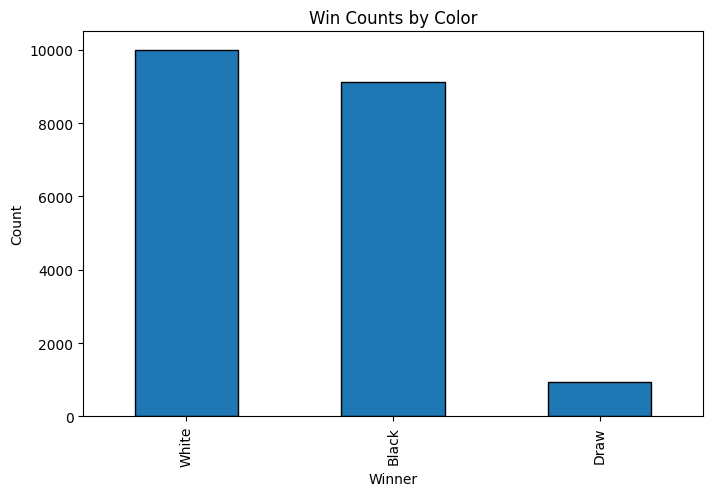

In [44]:
import os
os.makedirs('../output', exist_ok=True)
ax = merged['winner'].value_counts().plot(
    kind='bar',
    edgecolor='black',
    figsize=(8, 5),
    title='Win Counts by Color'
)

ax.set_xlabel('Winner')
ax.set_ylabel('Count')

ax.figure.savefig('../output/wins_by_color.png')

#### Q19 — Plot: scatter of white_rating vs turns for rated games. What do you observe?


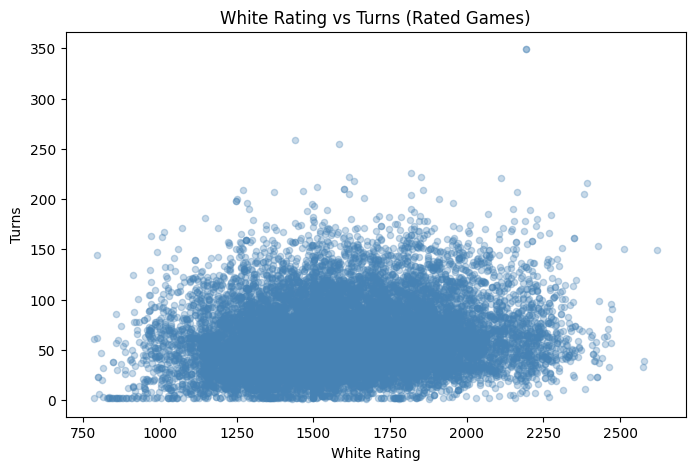

In [46]:
rated = merged[merged['rated'] == True]

ax = rated.plot(
    kind='scatter',
    x='white_rating',
    y='turns',
    alpha=0.3,
    color='steelblue',
    figsize=(8, 5),
    title='White Rating vs Turns (Rated Games)'
)

ax.set_xlabel('White Rating')
ax.set_ylabel('Turns')

ax.figure.savefig('../output/white_rating_vs_turns.png')

#### Q19 Observation:
- Most games end between 25-120 turns regardless of rating
- Beginner players (rating < 1000) tend to have shorter games
- Mid-level players (1200-1800) show the most variation in turn count
- High-rated players (rating > 2000) have fewer games but more consistent turn counts
- There are clear outliers — some games reached up to 350 turns!

#### Q20: Boxplot turns by victory_status

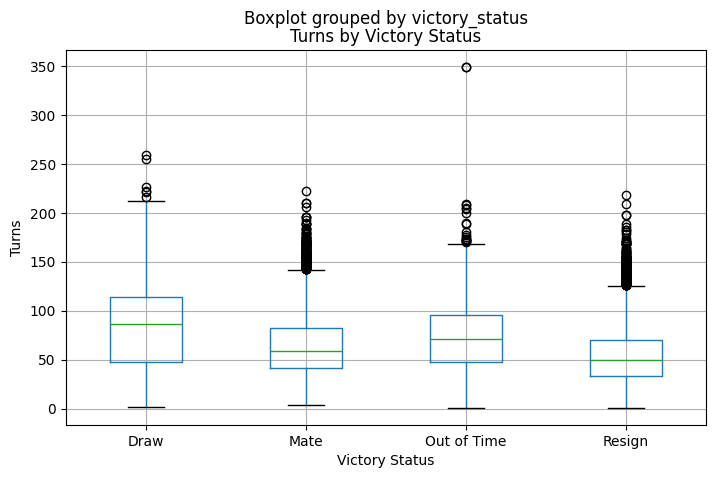

In [48]:
ax = games_df.boxplot(
    column='turns',
    by='victory_status',
    figsize=(8, 5)
)

ax.set_title('Turns by Victory Status')
ax.set_xlabel('Victory Status')
ax.set_ylabel('Turns')

ax.figure.savefig('../output/turns_by_victory_status.png')

#### Observation:
- Draw games have the highest median turns (~88) — they last the longest
- Out of Time is second (~70 turns)
- Mate games have a median of ~60 turns
- Resign games are the shortest (~50 turns) — players give up early
- All categories have outliers, with Out of Time reaching 350 turns!